In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

con = duckdb.connect("../data/intermediate/gdelt_main.db")

In [2]:
# =========================
# 1. VOLATILITY (FULL DATA - NO FILTER)
# =========================

con.execute("""
CREATE OR REPLACE TABLE narrative_volatility AS
SELECT
    country,
    year_month,

    STDDEV(tone_mean) OVER (
        PARTITION BY country
        ORDER BY year_month
        ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
    ) AS tone_vol,

    STDDEV(goldstein_mean) OVER (
        PARTITION BY country
        ORDER BY year_month
        ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
    ) AS goldstein_vol,

    STDDEV(quad_entropy) OVER (
        PARTITION BY country
        ORDER BY year_month
        ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
    ) AS entropy_vol

FROM narrative_country_month;
""")

In [3]:
# =========================
# 2. FILTER (ONLY HERE!)
# =========================

filtered_2025 = con.execute("""
SELECT country,
       SUM(event_count) AS total_events,
       MIN(event_count) AS min_monthly_events
FROM narrative_country_month
WHERE year_month BETWEEN DATE '2025-01-01' AND DATE '2025-12-31'
GROUP BY country
HAVING total_events >= 60
   AND min_monthly_events >= 10
""").fetchdf()

In [4]:
# =========================
# 3. SNAPSHOTS
# =========================

nvi_2025 = con.execute("""
SELECT v.country, v.tone_vol, v.goldstein_vol, v.entropy_vol
FROM narrative_volatility v
JOIN (
    SELECT country,
           SUM(event_count) AS total_events,
           MIN(event_count) AS min_monthly_events
    FROM narrative_country_month
    WHERE year_month BETWEEN DATE '2025-01-01' AND DATE '2025-12-31'
    GROUP BY country
) e
ON v.country = e.country
WHERE v.year_month = DATE '2025-12-01'
AND e.total_events >= 60
AND e.min_monthly_events >= 10
""").fetchdf()

nvi_2026 = con.execute("""
SELECT v.country, v.tone_vol, v.goldstein_vol, v.entropy_vol
FROM narrative_volatility v
JOIN (
    SELECT country,
           SUM(event_count) AS total_events,
           MIN(event_count) AS min_monthly_events
    FROM narrative_country_month
    WHERE year_month BETWEEN DATE '2025-01-01' AND DATE '2025-12-31'
    GROUP BY country
) e
ON v.country = e.country
WHERE v.year_month = DATE '2026-03-01'
AND e.total_events >= 60
AND e.min_monthly_events >= 10
""").fetchdf()

In [5]:
# =========================
# 4. RENAME
# =========================

nvi_2025 = nvi_2025.rename(columns={
    "tone_vol": "tone_2025",
    "goldstein_vol": "goldstein_2025",
    "entropy_vol": "entropy_2025"
})

nvi_2026 = nvi_2026.rename(columns={
    "tone_vol": "tone_2026",
    "goldstein_vol": "goldstein_2026",
    "entropy_vol": "entropy_2026"
})

In [6]:
# =========================
# 5. MERGE (SAME COUNTRIES)
# =========================

merged = nvi_2025.merge(nvi_2026, on="country", how="inner")

print("Countries used:", merged.shape[0])

Countries used: 211


In [7]:
# =========================
# 6. BASELINE NORMALIZATION (2025 ONLY)
# =========================

mu_tone = merged["tone_2025"].mean()
std_tone = merged["tone_2025"].std()

mu_gold = merged["goldstein_2025"].mean()
std_gold = merged["goldstein_2025"].std()

mu_entropy = merged["entropy_2025"].mean()
std_entropy = merged["entropy_2025"].std()

In [8]:
# =========================
# 7. NVI 2025 (BASELINE EXACT)
# =========================

merged["z_tone_2025"] = (merged["tone_2025"] - mu_tone) / std_tone
merged["z_gold_2025"] = (merged["goldstein_2025"] - mu_gold) / std_gold
merged["z_entropy_2025"] = (merged["entropy_2025"] - mu_entropy) / std_entropy

merged["NVI_2025"] = (
    merged["z_tone_2025"] +
    merged["z_gold_2025"] +
    merged["z_entropy_2025"]
)

In [9]:
# =========================
# 8. NVI 2026 (SAME SCALE)
# =========================

merged["z_tone_2026"] = (merged["tone_2026"] - mu_tone) / std_tone
merged["z_gold_2026"] = (merged["goldstein_2026"] - mu_gold) / std_gold
merged["z_entropy_2026"] = (merged["entropy_2026"] - mu_entropy) / std_entropy

merged["NVI_2026"] = (
    merged["z_tone_2026"] +
    merged["z_gold_2026"] +
    merged["z_entropy_2026"]
)

In [10]:
# =========================
# 9. DELTA NVI
# =========================

merged["delta_NVI"] = merged["NVI_2026"] - merged["NVI_2025"]

In [11]:
# =========================
# 10. VALIDATION (CRITICAL)
# =========================

baseline = con.execute("""
SELECT country, NVI
FROM narrative_nvi
""").fetchdf()

test = baseline.merge(merged[["country","NVI_2025"]], on="country")

test["diff"] = test["NVI"] - test["NVI_2025"]

print("MAX DIFF (should be ~0):", test["diff"].abs().max())

MAX DIFF (should be ~0): 1.2878587085651816e-14


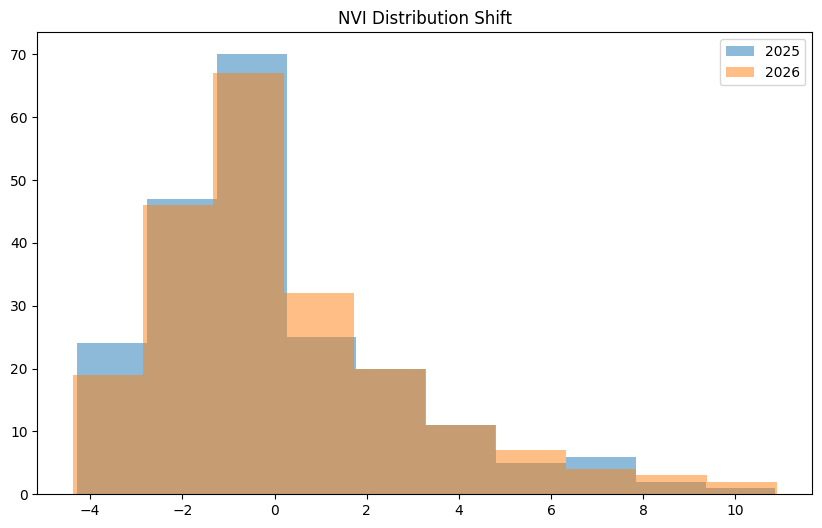

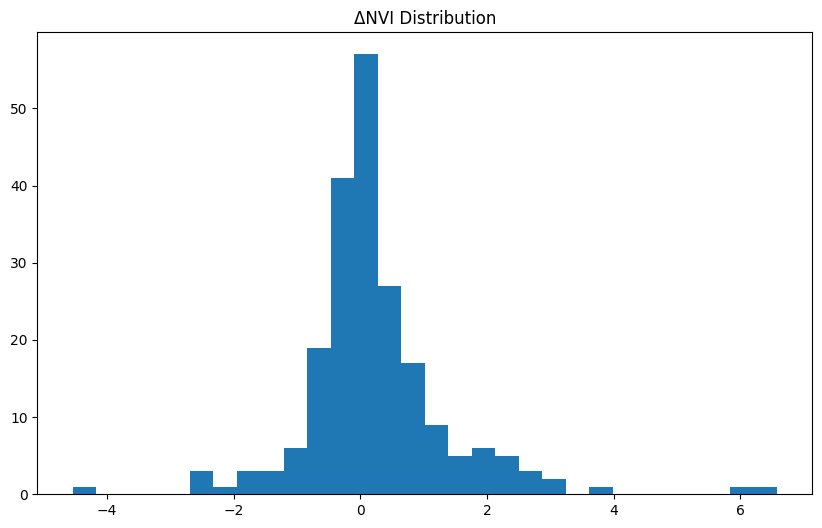

In [12]:
# =========================
# 11. PLOTS
# =========================

plt.figure(figsize=(10,6))
plt.hist(merged["NVI_2025"], alpha=0.5, label="2025")
plt.hist(merged["NVI_2026"], alpha=0.5, label="2026")
plt.legend()
plt.title("NVI Distribution Shift")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(merged["delta_NVI"], bins=30)
plt.title("ΔNVI Distribution")
plt.show()

In [13]:
# =========================
# 12. REGIME SHIFT
# =========================

q25 = merged["NVI_2025"].quantile(0.25)
q75 = merged["NVI_2025"].quantile(0.75)

def regime(x):
    if x > q75:
        return "Shock"
    elif x < q25:
        return "Stable"
    else:
        return "Moderate"

merged["regime_2025"] = merged["NVI_2025"].apply(regime)
merged["regime_2026"] = merged["NVI_2026"].apply(regime)

merged["regime_change"] = merged["regime_2025"] + " → " + merged["regime_2026"]

print("\nTop Positive Shifts:")
print(merged.sort_values("delta_NVI", ascending=False).head(10))

print("\nTop Negative Shifts:")
print(merged.sort_values("delta_NVI").head(10))

print("\nRegime transitions:")
print(merged["regime_change"].value_counts())


Top Positive Shifts:
    country  tone_2025  goldstein_2025  entropy_2025  tone_2026  \
20      BHR   0.699600        0.371824      0.101966   1.671565   
24      KWT   0.903482        0.318200      0.099835   1.570385   
50      ARE   0.488558        0.297023      0.105762   1.151420   
151     IRQ   0.396176        0.256226      0.045796   0.764312   
78      OMN   1.374369        0.295580      0.092966   1.918034   
29      SAU   0.377013        0.293076      0.088749   0.915531   
46      QAT   0.946249        0.448605      0.087527   1.165623   
43      MHL   0.695244        0.956498      0.198173   0.919910   
98      AFG   0.518709        0.526630      0.053982   0.820304   
178     IRN   0.405539        0.499924      0.067865   0.765937   

     goldstein_2026  entropy_2026  z_tone_2025  z_gold_2025  z_entropy_2025  \
20         1.159194      0.177227    -0.139520    -0.453397        0.079701   
24         1.425861      0.119324     0.365473    -0.645528        0.041407   
50 

In [14]:
middle_east = [
    "SAU", "ARE", "QAT", "KWT", "OMN", "BHR",
    "IRQ", "IRN", "ISR", "JOR", "LBN", "YEM", "SYR"
]

me_df = merged[merged["country"].isin(middle_east)].copy()

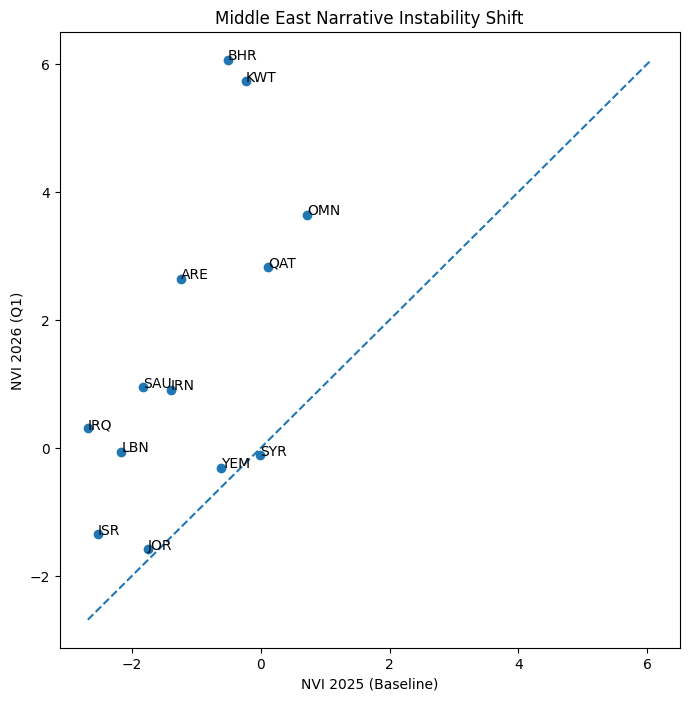

In [15]:
plt.figure(figsize=(8,8))

plt.scatter(me_df["NVI_2025"], me_df["NVI_2026"])

# diagonal line
min_val = min(me_df["NVI_2025"].min(), me_df["NVI_2026"].min())
max_val = max(me_df["NVI_2025"].max(), me_df["NVI_2026"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

# label countries
for _, row in me_df.iterrows():
    plt.text(row["NVI_2025"], row["NVI_2026"], row["country"])

plt.xlabel("NVI 2025 (Baseline)")
plt.ylabel("NVI 2026 (Q1)")
plt.title("Middle East Narrative Instability Shift")

plt.show()

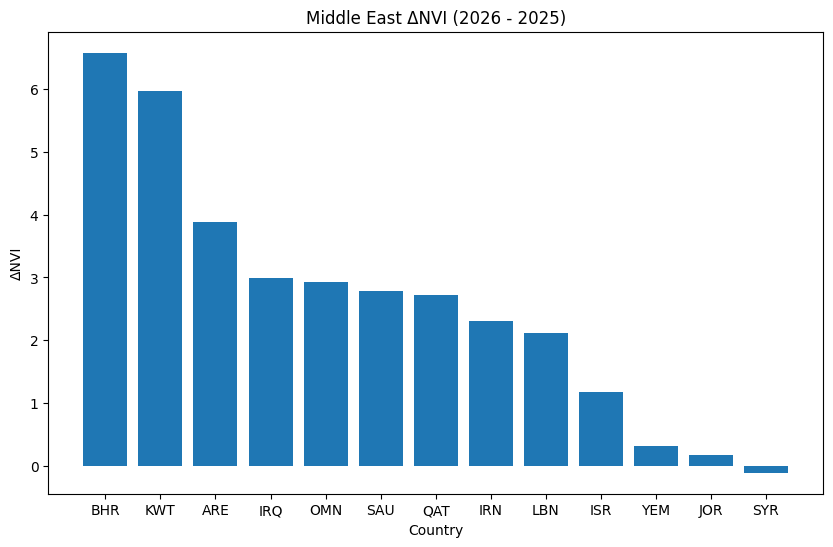

In [16]:
me_df = me_df.sort_values("delta_NVI", ascending=False)

plt.figure(figsize=(10,6))
plt.bar(me_df["country"], me_df["delta_NVI"])

plt.title("Middle East ΔNVI (2026 - 2025)")
plt.xlabel("Country")
plt.ylabel("ΔNVI")

plt.show()

In [17]:
middle_east = [
    "TUR","IRN","IRQ","SYR","SAU","ARE","QAT","KWT","OMN","BHR",
    "ISR","JOR","LBN","YEM"
]

me_table = merged[merged["country"].isin(middle_east)][[
    "country",
    "NVI_2025",
    "NVI_2026",
    "delta_NVI",
    "regime_2025",
    "regime_2026"
]].sort_values("delta_NVI", ascending=False)

print(me_table)

    country  NVI_2025  NVI_2026  delta_NVI regime_2025 regime_2026
20      BHR -0.513215  6.067970   6.581186    Moderate       Shock
24      KWT -0.238648  5.732120   5.970768    Moderate       Shock
50      ARE -1.235715  2.645284   3.880999    Moderate       Shock
151     IRQ -2.688478  0.302389   2.990867      Stable    Moderate
78      OMN  0.723203  3.646784   2.923581    Moderate       Shock
29      SAU -1.831909  0.949078   2.780987      Stable    Moderate
46      QAT  0.113307  2.825710   2.712403    Moderate       Shock
178     IRN -1.395491  0.910231   2.305722    Moderate    Moderate
74      LBN -2.167016 -0.059593   2.107423      Stable    Moderate
39      ISR -2.531581 -1.353440   1.178141      Stable    Moderate
124     YEM -0.618503 -0.308921   0.309582    Moderate    Moderate
8       JOR -1.754275 -1.585589   0.168687      Stable    Moderate
122     SYR -0.006359 -0.118648  -0.112289    Moderate    Moderate
145     TUR -1.025903 -2.249590  -1.223687    Moderate      St